In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, mean_squared_error, r2_score)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("dataset.csv")
print("=" * 60)
print("STUDENT PLACEMENT DATASET — REGRESSION ANALYSIS")
print("=" * 60)
print(f"\nShape: {df.shape}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nDescriptive Statistics:\n{df.describe().round(3)}")
print(f"\nMissing values: {df.isnull().sum().to_dict()}")


STUDENT PLACEMENT DATASET — REGRESSION ANALYSIS

Shape: (2966, 4)

First 5 rows:
   Internships  CGPA  HistoryOfBacklogs  PlacedOrNot
0            1     8                  1            1
1            0     7                  1            1
2            1     6                  0            1
3            0     8                  1            1
4            0     8                  0            1

Descriptive Statistics:
       Internships      CGPA  HistoryOfBacklogs  PlacedOrNot
count     2966.000  2966.000           2966.000     2966.000
mean         0.704     7.074              0.192        0.553
std          0.740     0.968              0.394        0.497
min          0.000     5.000              0.000        0.000
25%          0.000     6.000              0.000        0.000
50%          1.000     7.000              0.000        1.000
75%          1.000     8.000              0.000        1.000
max          3.000     9.000              1.000        1.000

Missing values: {'Internsh

In [3]:
print("\n" + "=" * 60)
print("MODEL 1: LINEAR REGRESSION (Target = CGPA)")
print("=" * 60)

X_lin = df[['Internships', 'HistoryOfBacklogs', 'PlacedOrNot']]
y_lin = df['CGPA']

X_lin_train, X_lin_test, y_lin_train, y_lin_test = train_test_split(
    X_lin, y_lin, test_size=0.2, random_state=42)

lin_model = LinearRegression()
lin_model.fit(X_lin_train, y_lin_train)
y_lin_pred = lin_model.predict(X_lin_test)

r2   = r2_score(y_lin_test, y_lin_pred)
rmse = np.sqrt(mean_squared_error(y_lin_test, y_lin_pred))
mae  = np.mean(np.abs(y_lin_test - y_lin_pred))

print(f"\nIntercept:    {lin_model.intercept_:.4f}")
print(f"Coefficients: {dict(zip(X_lin.columns, lin_model.coef_.round(4)))}")
print(f"\nR²   Score:   {r2:.4f}")
print(f"RMSE:         {rmse:.4f}")
print(f"MAE:          {mae:.4f}")


MODEL 1: LINEAR REGRESSION (Target = CGPA)

Intercept:    6.5038
Coefficients: {'Internships': np.float64(-0.1109), 'HistoryOfBacklogs': np.float64(0.0251), 'PlacedOrNot': np.float64(1.1867)}

R²   Score:   0.3035
RMSE:         0.8282
MAE:          0.7008


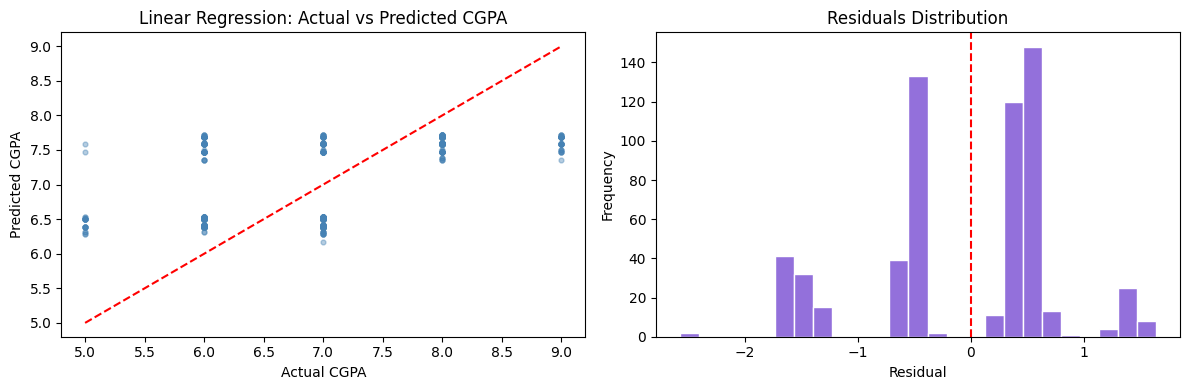

Saved: images/linear_regression_results.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_lin_test, y_lin_pred, alpha=0.4, color='steelblue', s=12)
axes[0].plot([5, 9], [5, 9], 'r--')
axes[0].set_xlabel("Actual CGPA")
axes[0].set_ylabel("Predicted CGPA")
axes[0].set_title("Linear Regression: Actual vs Predicted CGPA")

residuals = y_lin_test - y_lin_pred
axes[1].hist(residuals, bins=25, color='mediumpurple', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residuals Distribution")

plt.tight_layout()
plt.savefig("images/linear_regression_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: images/linear_regression_results.png")

In [5]:
print("\n" + "=" * 60)
print("MODEL 2: LOGISTIC REGRESSION (Target = PlacedOrNot)")
print("=" * 60)

X_log = df[['Internships', 'CGPA', 'HistoryOfBacklogs']]
y_log = df['PlacedOrNot']

X_log_train, X_log_test, y_log_train, y_log_test = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_log_train_s = scaler.fit_transform(X_log_train)
X_log_test_s  = scaler.transform(X_log_test)

log_model = LogisticRegression(random_state=42)
log_model.fit(X_log_train_s, y_log_train)
y_log_pred = log_model.predict(X_log_test_s)

acc = accuracy_score(y_log_test, y_log_pred)
cm  = confusion_matrix(y_log_test, y_log_pred)

print(f"\nCoefficients: {dict(zip(X_log.columns, log_model.coef_[0].round(4)))}")
print(f"Intercept:    {log_model.intercept_[0]:.4f}")
print(f"\nAccuracy:     {acc:.4f}")
print(f"\nConfusion Matrix:\n{cm}")
print(f"\nClassification Report:\n{classification_report(y_log_test, y_log_pred)}")


MODEL 2: LOGISTIC REGRESSION (Target = PlacedOrNot)

Coefficients: {'Internships': np.float64(0.5615), 'CGPA': np.float64(1.7873), 'HistoryOfBacklogs': np.float64(-0.0517)}
Intercept:    0.3855

Accuracy:     0.7340

Confusion Matrix:
[[201  79]
 [ 79 235]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.72      0.72       280
           1       0.75      0.75      0.75       314

    accuracy                           0.73       594
   macro avg       0.73      0.73      0.73       594
weighted avg       0.73      0.73      0.73       594



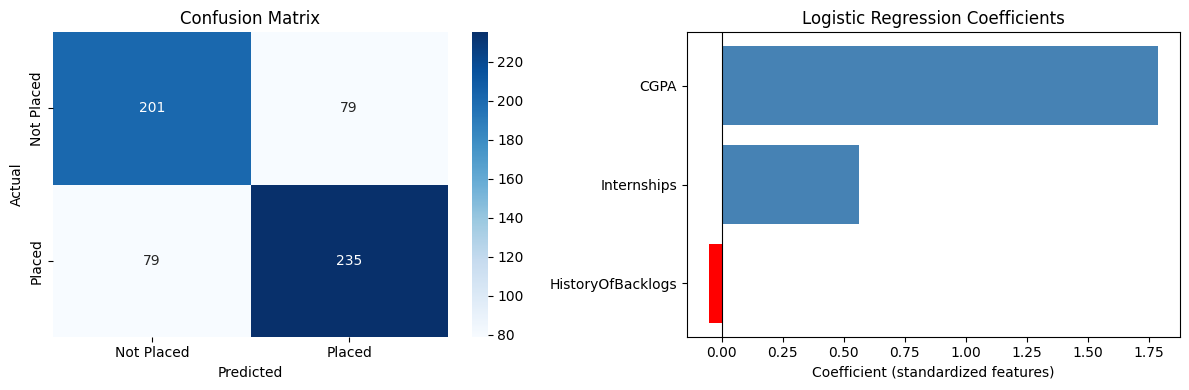

Saved: images/logistic_regression_results.png

ANALYSIS COMPLETE


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Placed','Placed'],
            yticklabels=['Not Placed','Placed'])
axes[0].set_title("Confusion Matrix")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

coef_df = pd.DataFrame({
    "Feature": list(X_log.columns),
    "Coefficient": log_model.coef_[0]
}).sort_values("Coefficient", ascending=True)
colors = ['red' if v < 0 else 'steelblue' for v in coef_df['Coefficient']]
axes[1].barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title("Logistic Regression Coefficients")
axes[1].set_xlabel("Coefficient (standardized features)")

plt.tight_layout()
plt.savefig("images/logistic_regression_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: images/logistic_regression_results.png")

print("\n" + "=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)
